In [9]:
import numpy as np
import matplotlib.pyplot as plt
import psi4
import fortecubeview
import shutil
from scipy.optimize import curve_fit
from pib_helper import create_psi4_molecule

<a id="part3"></a>

## Part 3 — Computational Chemistry

So far we have worked with the particle-in-a-box as a simplified model. Now we use quantum chemistry software to compute the electronic structure of **real molecules** and see how the model holds up.

We use the **Hartree–Fock (Self-Consistent Field, SCF)** method, which handles many interacting electrons by assuming each electron moves in the average field created by all the others. The procedure is:

1. **Initial guess** — build approximate orbitals from a set of basis functions (the **basis set**).
2. **Build the Fock operator** — an effective one-electron Hamiltonian including kinetic energy, nuclear attraction, and mean-field electron repulsion:
$$\hat{F}\psi_i = \varepsilon_i \psi_i$$
3. **Solve for new orbitals** — find orbital shapes and energies.
4. **Iterate** — repeat until the orbitals stop changing (**convergence**).

This is the same strategy as Part 1: start from a guess, minimize the energy, and let the physics determine the answer.

### HOMO–LUMO Gap

Each orbital holds two electrons (spin-up and spin-down). The highest filled orbital is the **HOMO** and the lowest empty orbital is the **LUMO**. Their energy difference

$$\Delta E = E_{\text{LUMO}} - E_{\text{HOMO}}$$

determines the energy of light the molecule can absorb. In Part 4 we will compare these gaps to the particle-in-a-box prediction.

---

### Coding Activity 3
`30 points`

- C4.3: Apply the particle-in-a-box model to conjugated polyenes.
- P4.3: Perform quantum chemical calculations with `psi4`.

#### Part A — Running a Hartree–Fock calculation

The cell below runs an HF/STO-3G calculation on **ethane** and plots its orbital energies. Run it and **add a comment to every line** explaining what it does.

Then, in the next cell, run the same calculation on **octatetraene** (`C=CC=CC=CC=C`) and plot its orbital energies.

Ethane HF/STO-3G energy: -78.305577 a.u.


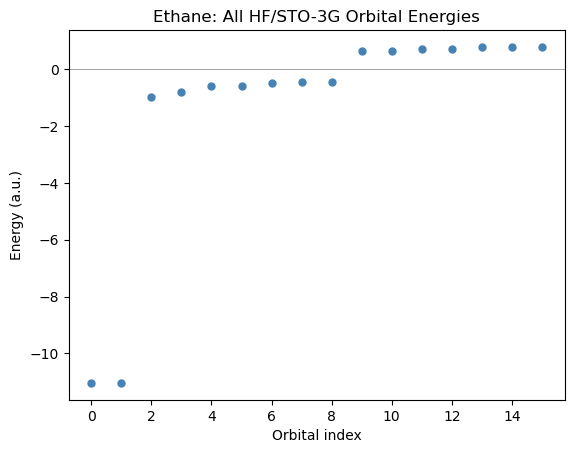

In [10]:
# --- Worked example: ethane ---
psi4.set_output_file('output.dat', False)
psi4.set_memory('1 GB')

mol_ethane = create_psi4_molecule('CC')
energy_ethane, wfn_ethane = psi4.energy('SCF/STO-3G', return_wfn=True, molecule=mol_ethane)
print(f'Ethane HF/STO-3G energy: {energy_ethane:.6f} a.u.')

# Plot all orbital energies
eps_ethane = wfn_ethane.epsilon_a().np
plt.plot(eps_ethane, 'o', markersize=5, color='steelblue')
plt.axhline(0, color='grey', linewidth=0.5)
plt.xlabel('Orbital index')
plt.ylabel('Energy (a.u.)')
plt.title('Ethane: All HF/STO-3G Orbital Energies')
plt.show()

Octatetraene HF/STO-3G energy: -304.908014 a.u.


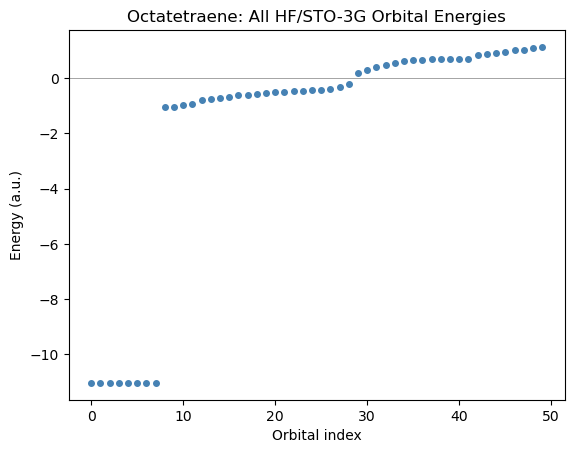

In [11]:
# Octatetraene
psi4.set_output_file('output.dat', False)
psi4.set_memory('1 GB')

mol_oct = create_psi4_molecule('C=CC=CC=CC=C')
energy_oct, wfn_oct = psi4.energy('SCF/STO-3G', return_wfn=True, molecule=mol_oct)
print(f'Octatetraene HF/STO-3G energy: {energy_oct:.6f} a.u.')

# Plot all orbital energies
eps = wfn_oct.epsilon_a().np
plt.plot(eps, 'o', markersize=4, color='steelblue')
plt.axhline(0, color='grey', linewidth=0.5)
plt.xlabel('Orbital index')
plt.ylabel('Energy (a.u.)')
plt.title('Octatetraene: All HF/STO-3G Orbital Energies')
plt.show()

#### Part B — Visualizing molecular orbitals

The cell below generates cube files for orbitals near the HOMO and LUMO of octatetraene and displays them with `fortecubeview`. Run it, then examine the orbital shapes.

Octatetraene (C$_8$H$_{10}$) has $N_e = 58$ electrons, so the HOMO is orbital index 28 (zero-indexed).

**Your task:** identify which of the displayed orbitals are **$\pi$ orbitals** — they have lobes above and below the molecular plane. Record their indices; you will use them in Part C.

In [ ]:
# --- Given: orbital visualization ---
import os
os.makedirs('cubes', exist_ok=True)

# psi4 CUBEPROP_ORBITALS uses 1-indexed orbital numbers
homo_psi4 = 29  # octatetraene HOMO (1-indexed; 58 electrons / 2 = 29)
orb_numbers = list(range(homo_psi4 - 4, homo_psi4 + 5))  # [25, 26, 27, 28, 29, 30, 31, 32, 33]

psi4.set_options({
    'CUBEPROP_TASKS': ['orbitals'],
    'CUBEPROP_FILEPATH': 'cubes',
    'CUBEPROP_ORBITALS': orb_numbers,
})
psi4.cubeprop(wfn_oct)
fortecubeview.plot('cubes', colorscheme='wow')

CubeViewer: listing cube files from the directory cubes
Reading 9 cube files


HTML(value='\n        <style>\n           .jupyter-widgets-output-area .output_scroll {\n                heigh…

interactive(children=(Select(description='Cube files:', options=('MO   25a (25-A)', 'MO   26a (26-A)', 'MO   2…

In [ ]:
# Run this cell when you are done inspecting orbitals
#shutil.rmtree('cubes', ignore_errors=True)

In [ ]:
# The four occupied pi and four unoccupied pi* orbitals of octatetraene
# we need to subtract 1, because fortecubeview uses 1-based indexing
# but psi4 uses 0-based indexing
pi_indices = np.array([25, 27, 28, 29, 30, 31, 32, 33]) - 1

#### Part C — Fitting the PIB model to $\pi$ orbital energies

Plot only the $\pi$ orbital energies, then try to fit the particle-in-a-box model $E = A \cdot n^2$ to them using `curve_fit`. Does the PIB model capture the pattern?

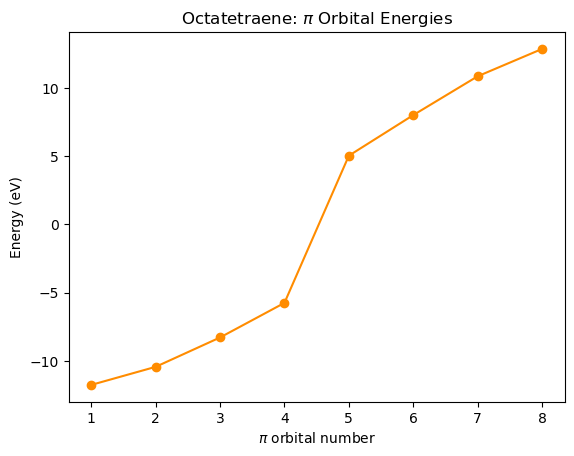

In [19]:
# Subgoal: Plot pi orbital energies and fit PIB model
AU_TO_EV = 27.211
pi_energies = eps[pi_indices] * AU_TO_EV
n_pi = np.arange(1, len(pi_energies) + 1)
# Plot pi energies
plt.plot(n_pi, pi_energies, 'o-', color='darkorange')
plt.xlabel(r'$\pi$ orbital number')
plt.ylabel('Energy (eV)')
plt.title(r'Octatetraene: $\pi$ Orbital Energies')
plt.show()

In [20]:
# Fit E = A * n^2 + b
def pib_model(n, A,b):
    return A * n**2 + b

popt, pcov = curve_fit(pib_model, n_pi, pi_energies)
print(f"Fitted: E = {popt[0]:.4f} * n^2")


Fitted: E = 0.4300 * n^2


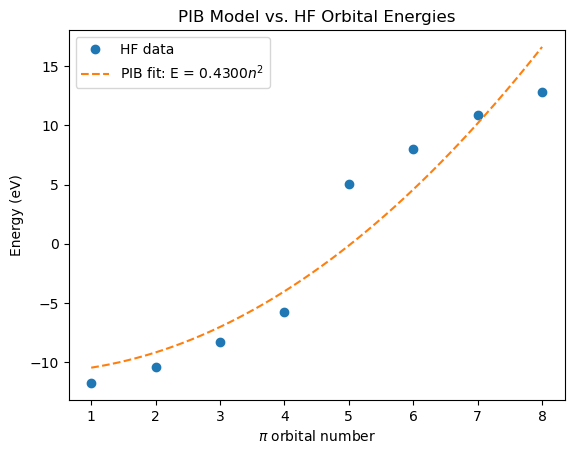

In [21]:

# Plot data vs fit
n_fine = np.linspace(1, len(pi_energies), 50)
plt.plot(n_pi, pi_energies, 'o', label='HF data')
plt.plot(n_fine, pib_model(n_fine, *popt), '--', label=f'PIB fit: E = {popt[0]:.4f}$n^2$')
plt.xlabel(r'$\pi$ orbital number')
plt.ylabel('Energy (eV)')
plt.title('PIB Model vs. HF Orbital Energies')
plt.legend()
plt.show()

### Question 3
`15 points`

- C4.2: Explain features of particle-in-a-box wavefunctions and their energies.
- C4.4: Evaluate the tradeoffs of different physical models.

a) Compare the Hartree–Fock procedure to the variational minimization you did in Part 1. What is conceptually the same? What is different?

b) Look at the $\pi$ orbitals of octatetraene. In what ways do they resemble the particle-in-a-box wavefunctions from Part 2?

c) How well does the PIB model $E = An^2$ fit the $\pi$ orbital energies? What does this tell you about the limitations of the particle-in-a-box as a model for real molecules?

---

*Your answer here (`double click me!`):*

**Model answers:**

a) Both methods start from a trial guess and iteratively minimize the energy — this is the variational principle. The difference is scale: in Part 1 we optimized one wavefunction on a 1D grid. HF simultaneously optimizes many coupled orbitals in 3D with a realistic Hamiltonian and explicit electron–electron interactions.

b) The $\pi$ orbitals have the same qualitative node structure: the lowest $\pi$ orbital has no nodes along the chain, and each successive orbital adds one node — just like the PIB wavefunctions $\psi_n$ with $n-1$ nodes.

c) The PIB model $E = An^2$ does not fit the $\pi$ orbital energies well. The real orbital energies include effects absent from the PIB: electron–electron repulsion, non-uniform potential along the chain, and the fact that the "walls" of the molecular box are soft rather than infinite. The PIB captures the qualitative ordering but not the quantitative spacing.

---